In [1]:
%matplotlib inline

from collections import Counter, defaultdict
from itertools import tee
import json
from pathlib import Path
import statistics

import matplotlib.pyplot as plt

TRACE_PATH = Path("../outputs/phase2_m3cot_traces.jsonl")
if not TRACE_PATH.exists():
    TRACE_PATH = Path("outputs/phase2_m3cot_traces.jsonl")

INCLUDE_STOP_ACTION = False

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

TRACE_PATH

PosixPath('../outputs/phase2_m3cot_traces.jsonl')

## Load Traces

In [2]:
def load_jsonl(path):
    rows = []
    bad_rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()
            if not stripped:
                continue
            try:
                rows.append(json.loads(stripped))
            except json.JSONDecodeError as exc:
                bad_rows.append(
                    {
                        "line_number": line_number,
                        "error": str(exc),
                        "position": exc.pos,
                        "context": stripped[max(0, exc.pos - 120): exc.pos + 120],
                    }
                )
    return rows, bad_rows

if not TRACE_PATH.exists():
    raise FileNotFoundError(f"Trace file not found: {TRACE_PATH.resolve()}")

rows, bad_rows = load_jsonl(TRACE_PATH)

print(f"Trace file: {TRACE_PATH.resolve()}")
print(f"Valid rows loaded: {len(rows):,}")
print(f"Invalid JSONL rows: {len(bad_rows):,}")

if bad_rows:
    print("\nFirst invalid row:")
    first_bad = bad_rows[0]
    print(f"  line_number: {first_bad['line_number']}")
    print(f"  error: {first_bad['error']}")
    print(f"  context: {first_bad['context']}")

if rows:
    print("\nExample row keys:", sorted(rows[0].keys()))

Trace file: /home/csalt/Haider/DVLM/lvar/outputs/phase2_m3cot_traces.jsonl
Valid rows loaded: 4,448
Invalid JSONL rows: 0

Example row keys: ['answer', 'counterfactual_pairs', 'decisions', 'example_id', 'initial_visual_mode', 'question', 'steps', 'trace']


## Flatten Controller Actions

In [3]:
def flatten_actions(row, include_stop=False):
    actions = []
    for decision in row.get("decisions", []) or []:
        for action in decision.get("actions", []) or []:
            actions.append(dict(action))
    if include_stop:
        actions.append({"type": "STOP"})
    return actions

def decision_is_noop(decision):
    selected = str(decision.get("selected", "")).upper()
    actions = decision.get("actions", []) or []
    return selected == "NO_OP" or len(actions) == 0

def pairwise(iterable):
    a, b = tee(iterable)
    next(b, None)
    return zip(a, b)

analysis_rows = []
all_actions = []
all_decision_names = []

for row_index, row in enumerate(rows):
    decisions = row.get("decisions", []) or []
    actions = flatten_actions(row, include_stop=INCLUDE_STOP_ACTION)
    action_types = [str(action.get("type", "UNKNOWN")).upper() for action in actions]
    noop_count = sum(1 for decision in decisions if decision_is_noop(decision))
    decision_names = [str(decision.get("selected", "UNKNOWN")).upper() for decision in decisions]
    all_decision_names.extend(decision_names)
    all_actions.extend(actions)
    analysis_rows.append(
        {
            "row_index": row_index,
            "example_id": row.get("example_id"),
            "num_decisions": len(decisions),
            "num_actions": len(actions),
            "num_noops": noop_count,
            "action_types": action_types,
            "actions": actions,
        }
    )

print(f"Rows analyzed: {len(analysis_rows):,}")
print(f"Primitive controller actions analyzed: {len(all_actions):,}")
print(f"Implicit STOP included: {INCLUDE_STOP_ACTION}")

Rows analyzed: 4,448
Primitive controller actions analyzed: 48,010
Implicit STOP included: False


## Basic Metrics

In [4]:
action_lengths = [item["num_actions"] for item in analysis_rows]
decision_lengths = [item["num_decisions"] for item in analysis_rows]
noop_lengths = [item["num_noops"] for item in analysis_rows]

if not action_lengths:
    raise ValueError("No valid trace rows were loaded; cannot compute metrics.")

print("Controller action sequence length per example")
print(f"  min steps: {min(action_lengths):,}")
print(f"  max steps: {max(action_lengths):,}")
print(f"  avg steps: {statistics.mean(action_lengths):.3f}")
print(f"  median steps: {statistics.median(action_lengths):.3f}")

print("\nDecision count per example")
print(f"  min decisions: {min(decision_lengths):,}")
print(f"  max decisions: {max(decision_lengths):,}")
print(f"  avg decisions: {statistics.mean(decision_lengths):.3f}")

print("\nNO_OP decisions per example")
print(f"  total NO_OP decisions: {sum(noop_lengths):,}")
print(f"  avg NO_OP decisions: {statistics.mean(noop_lengths):.3f}")
print(f"  examples with at least one NO_OP: {sum(1 for n in noop_lengths if n > 0):,}")

Controller action sequence length per example
  min steps: 1
  max steps: 27
  avg steps: 10.794
  median steps: 11.000

Decision count per example
  min decisions: 2
  max decisions: 8
  avg decisions: 6.448

NO_OP decisions per example
  total NO_OP decisions: 4,519
  avg NO_OP decisions: 1.016
  examples with at least one NO_OP: 2,548


## Most Common Actions, Patches, And Regions

In [5]:
action_counter = Counter(str(action.get("type", "UNKNOWN")).upper() for action in all_actions)
patch_counter = Counter(int(action["patch_idx"]) for action in all_actions if str(action.get("type", "")).upper() == "PATCH" and "patch_idx" in action)
region_counter = Counter(int(action["region_idx"]) for action in all_actions if str(action.get("type", "")).upper() == "REGION" and "region_idx" in action)
decision_counter = Counter(all_decision_names)

def print_top(counter, title, n=10):
    print(title)
    if not counter:
        print("  None found")
        return
    total = sum(counter.values())
    for key, count in counter.most_common(n):
        print(f"  {key}: {count:,} ({count / total:.2%})")

print_top(action_counter, "Most common primitive action types")
print()
print_top(patch_counter, "Most common patch indices")
print()
print_top(region_counter, "Most common region indices")
print()
print_top(decision_counter, "Most common high-level selected decisions")

Most common primitive action types
  PATCH: 34,905 (72.70%)
  REGION: 10,015 (20.86%)
  THINK: 2,787 (5.81%)
  GLOBAL: 303 (0.63%)

Most common patch indices
  99: 1,292 (3.70%)
  4: 808 (2.31%)
  7: 617 (1.77%)
  89: 596 (1.71%)
  61: 520 (1.49%)
  0: 498 (1.43%)
  71: 494 (1.42%)
  91: 494 (1.42%)
  92: 491 (1.41%)
  62: 487 (1.40%)

Most common region indices
  24: 994 (9.93%)
  2: 596 (5.95%)
  20: 463 (4.62%)
  15: 456 (4.55%)
  21: 446 (4.45%)
  1: 440 (4.39%)
  16: 423 (4.22%)
  23: 416 (4.15%)
  4: 397 (3.96%)
  3: 387 (3.86%)

Most common high-level selected decisions
  PATCH_SEQ: 12,415 (43.28%)
  REGION: 8,859 (30.89%)
  NO_OP: 4,519 (15.76%)
  PATCH_SEQ_THINK: 1,186 (4.13%)
  REGION_THINK: 1,156 (4.03%)
  THINK: 244 (0.85%)
  GLOBAL_THINK: 201 (0.70%)
  GLOBAL: 102 (0.36%)


## Repetition Within A Sequence

In [6]:
def repetition_metrics(action_types):
    if not action_types:
        return {
            "adjacent_repeats": 0,
            "adjacent_repeat_rate": 0.0,
            "unique_action_types": 0,
            "duplicate_action_type_count": 0,
            "max_run_length": 0,
        }
    adjacent_repeats = sum(1 for left, right in pairwise(action_types) if left == right)
    runs = []
    current = action_types[0]
    run_length = 1
    for action_type in action_types[1:]:
        if action_type == current:
            run_length += 1
        else:
            runs.append(run_length)
            current = action_type
            run_length = 1
    runs.append(run_length)
    unique_count = len(set(action_types))
    return {
        "adjacent_repeats": adjacent_repeats,
        "adjacent_repeat_rate": adjacent_repeats / max(1, len(action_types) - 1),
        "unique_action_types": unique_count,
        "duplicate_action_type_count": len(action_types) - unique_count,
        "max_run_length": max(runs),
    }

for item in analysis_rows:
    item.update(repetition_metrics(item["action_types"]))

adjacent_repeat_rates = [item["adjacent_repeat_rate"] for item in analysis_rows]
max_run_lengths = [item["max_run_length"] for item in analysis_rows]
duplicate_counts = [item["duplicate_action_type_count"] for item in analysis_rows]

print("Within-sequence action type repetition")
print(f"  examples with adjacent repeats: {sum(1 for item in analysis_rows if item['adjacent_repeats'] > 0):,}")
print(f"  avg adjacent repeat rate: {statistics.mean(adjacent_repeat_rates):.3f}")
print(f"  max adjacent repeat rate: {max(adjacent_repeat_rates):.3f}")
print(f"  avg duplicate action-type count: {statistics.mean(duplicate_counts):.3f}")
print(f"  max run length of same action type: {max(max_run_lengths):,}")

print("\nExamples with highest adjacent repeat rate")
for item in sorted(analysis_rows, key=lambda x: (x["adjacent_repeat_rate"], x["num_actions"]), reverse=True)[:10]:
    print(
        f"  example_id={item['example_id']} steps={item['num_actions']} "
        f"repeat_rate={item['adjacent_repeat_rate']:.2%} actions={item['action_types']}"
    )

Within-sequence action type repetition
  examples with adjacent repeats: 4,360
  avg adjacent repeat rate: 0.680
  max adjacent repeat rate: 1.000
  avg duplicate action-type count: 8.266
  max run length of same action type: 24

Examples with highest adjacent repeat rate
  example_id=mathematics-580 steps=22 repeat_rate=100.00% actions=['PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH']
  example_id=geography-3002 steps=22 repeat_rate=100.00% actions=['PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH']
  example_id=physics-615 steps=20 repeat_rate=100.00% actions=['PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 'PATCH', 

## Histogram Of Controller Action Sequence Lengths

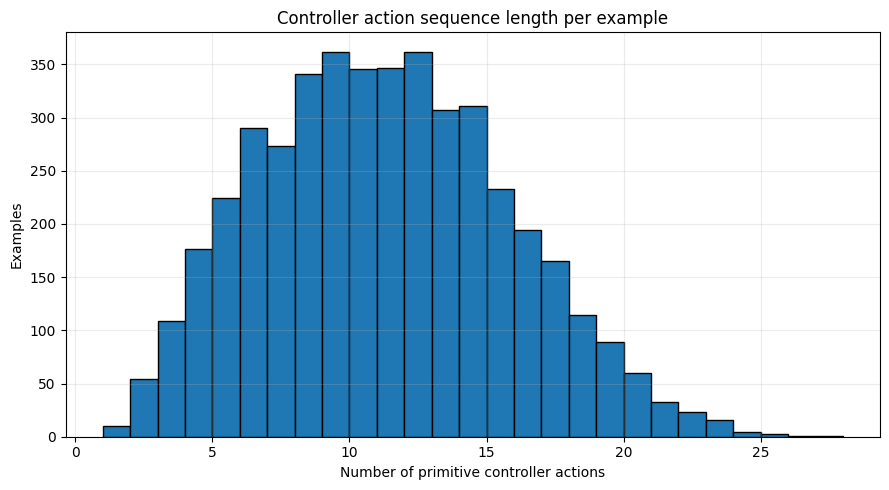

In [7]:
bins = range(min(action_lengths), max(action_lengths) + 2)
plt.figure()
plt.hist(action_lengths, bins=bins, edgecolor="black")
plt.title("Controller action sequence length per example")
plt.xlabel("Number of primitive controller actions")
plt.ylabel("Examples")
plt.tight_layout()
plt.show()

## Additional Matplotlib Plots

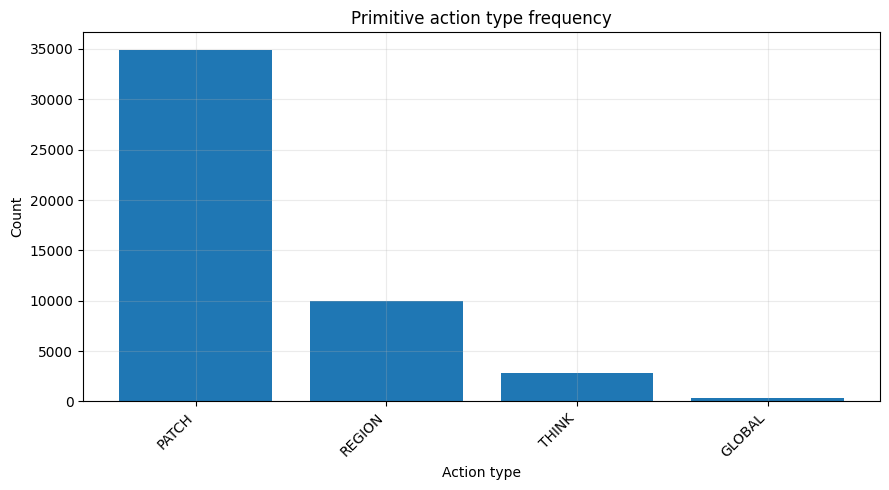

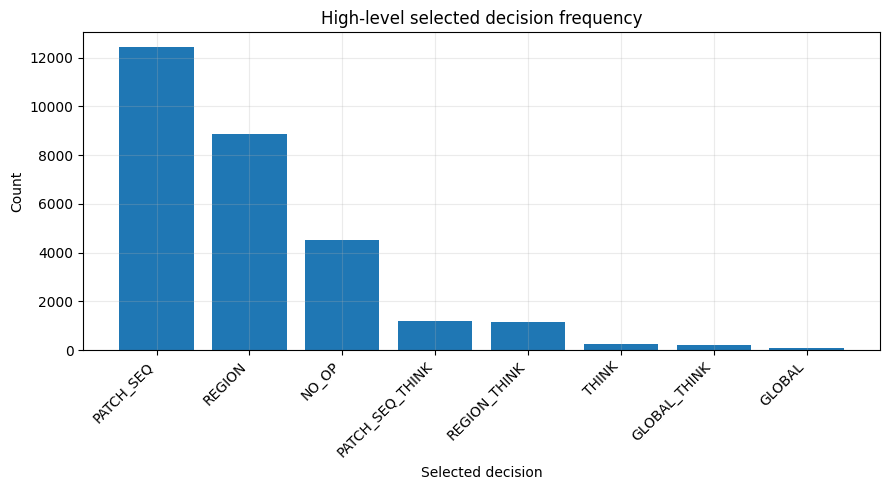

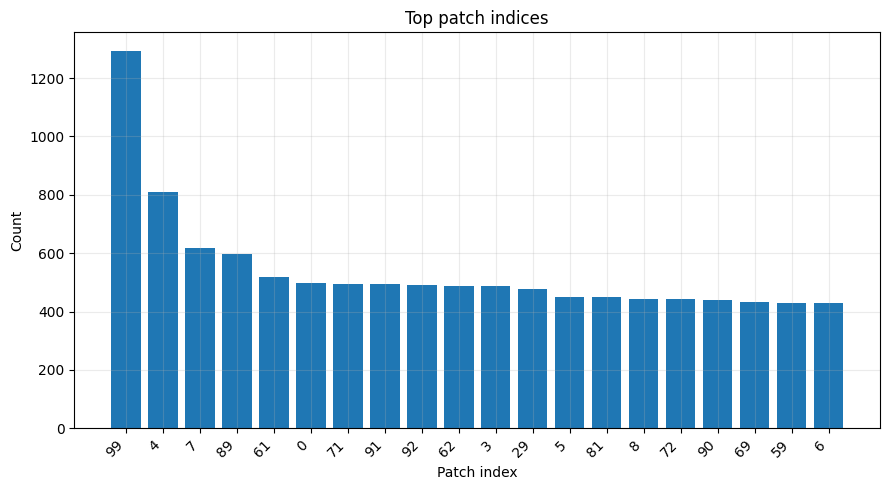

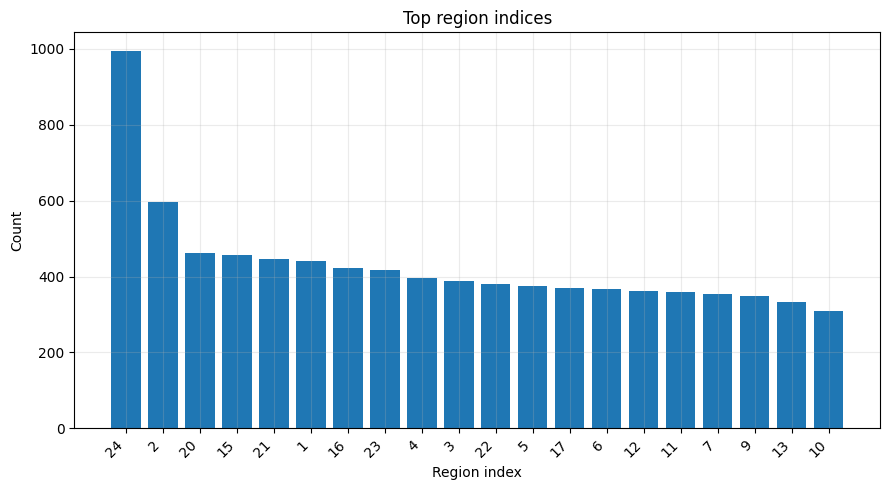

In [8]:
def bar_from_counter(counter, title, xlabel, ylabel="Count", top_n=20):
    if not counter:
        print(f"Skipping '{title}' because there is no data.")
        return
    items = counter.most_common(top_n)
    labels = [str(key) for key, _ in items]
    values = [value for _, value in items]
    plt.figure()
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

bar_from_counter(action_counter, "Primitive action type frequency", "Action type")
bar_from_counter(decision_counter, "High-level selected decision frequency", "Selected decision")
bar_from_counter(patch_counter, "Top patch indices", "Patch index")
bar_from_counter(region_counter, "Top region indices", "Region index")

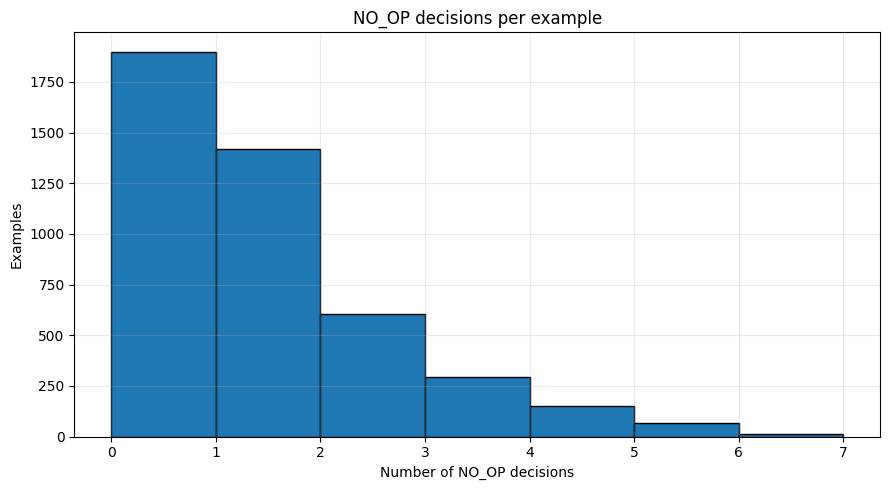

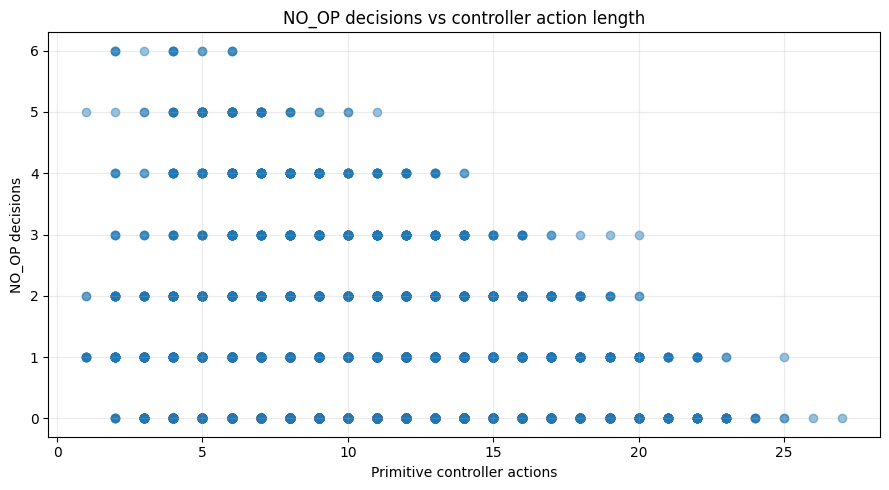

In [9]:
plt.figure()
plt.hist(noop_lengths, bins=range(min(noop_lengths), max(noop_lengths) + 2), edgecolor="black")
plt.title("NO_OP decisions per example")
plt.xlabel("Number of NO_OP decisions")
plt.ylabel("Examples")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(action_lengths, noop_lengths, alpha=0.45)
plt.title("NO_OP decisions vs controller action length")
plt.xlabel("Primitive controller actions")
plt.ylabel("NO_OP decisions")
plt.tight_layout()
plt.show()

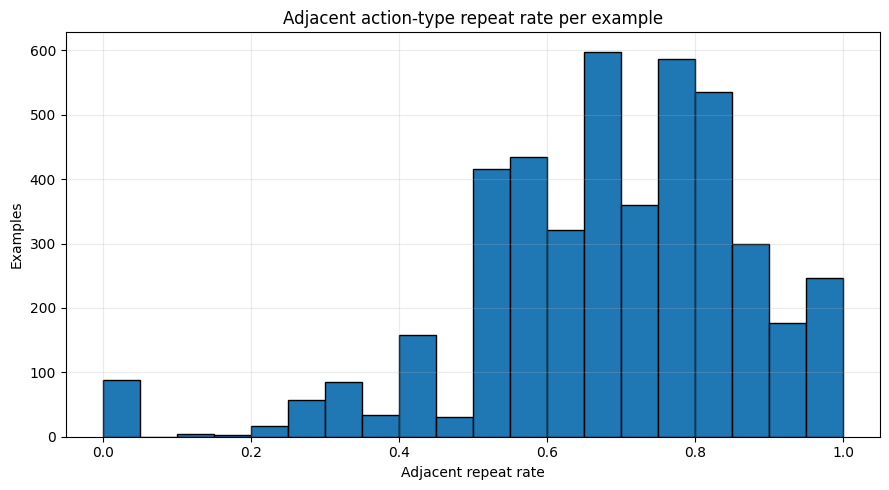

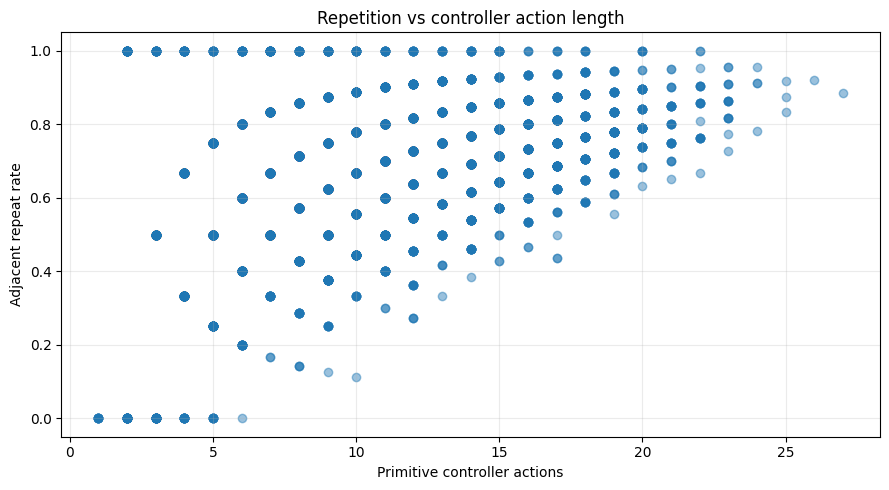

In [10]:
plt.figure()
plt.hist(adjacent_repeat_rates, bins=20, edgecolor="black")
plt.title("Adjacent action-type repeat rate per example")
plt.xlabel("Adjacent repeat rate")
plt.ylabel("Examples")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(action_lengths, adjacent_repeat_rates, alpha=0.45)
plt.title("Repetition vs controller action length")
plt.xlabel("Primitive controller actions")
plt.ylabel("Adjacent repeat rate")
plt.tight_layout()
plt.show()

## Transition Analysis

Most common adjacent action transitions
  PATCH -> PATCH: 27,697 (63.58%)
  PATCH -> REGION: 4,639 (10.65%)
  REGION -> PATCH: 4,412 (10.13%)
  REGION -> REGION: 3,399 (7.80%)
  PATCH -> THINK: 1,324 (3.04%)
  REGION -> THINK: 1,254 (2.88%)
  GLOBAL -> THINK: 206 (0.47%)
  THINK -> PATCH: 172 (0.39%)
  PATCH -> GLOBAL: 153 (0.35%)
  REGION -> GLOBAL: 117 (0.27%)
  THINK -> REGION: 102 (0.23%)
  GLOBAL -> PATCH: 48 (0.11%)
  GLOBAL -> REGION: 35 (0.08%)
  GLOBAL -> GLOBAL: 3 (0.01%)
  THINK -> THINK: 1 (0.00%)


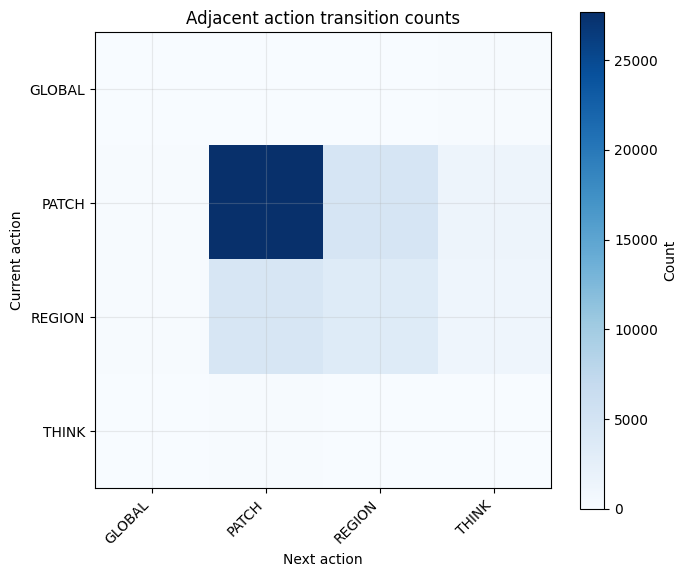

In [11]:
transition_counter = Counter()
for item in analysis_rows:
    transition_counter.update(pairwise(item["action_types"]))

print_top(Counter({f"{left} -> {right}": count for (left, right), count in transition_counter.items()}), "Most common adjacent action transitions", n=15)

action_labels = sorted(action_counter)
if action_labels and transition_counter:
    label_to_idx = {label: idx for idx, label in enumerate(action_labels)}
    matrix = [[0 for _ in action_labels] for _ in action_labels]
    for (left, right), count in transition_counter.items():
        matrix[label_to_idx[left]][label_to_idx[right]] = count

    plt.figure(figsize=(7, 6))
    plt.imshow(matrix, cmap="Blues")
    plt.title("Adjacent action transition counts")
    plt.xticks(range(len(action_labels)), action_labels, rotation=45, ha="right")
    plt.yticks(range(len(action_labels)), action_labels)
    plt.xlabel("Next action")
    plt.ylabel("Current action")
    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()